# Heartbeat Dataset Exploration

Notebook này thực hiện data exploration cho các heartbeat datasets:
- MIT-BIH Arrhythmia Database (mitbih_train.csv, mitbih_test.csv)
- PTBDB Database (ptbdb_normal.csv, ptbdb_abnormal.csv)

**Lưu ý:** Không explore broken_signals folder theo yêu cầu.


**Nhận xét về Setup:**
- Notebook được cấu hình để tự động xác định đường dẫn dataset từ thư mục research
- Dataset được chuẩn hóa với 5 classes cho MIT-BIH (0-4) tương ứng với các loại nhịp tim khác nhau
- Sử dụng seaborn darkgrid style để visualization rõ ràng hơn


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Class names for MIT-BIH dataset
CLASS_NAMES = {
    0: 'Non-Ectopic Beats',
    1: 'Superventrical Ectopic', 
    2: 'Ventricular Beats',
    3: 'Unknown',
    4: 'Fusion Beats'
}

# Paths - Adjust based on notebook location (src/research/)
NOTEBOOK_DIR = Path.cwd()
# If running from src/research/, go up 2 levels to project root
if NOTEBOOK_DIR.name == 'research':
    BASE_DIR = NOTEBOOK_DIR.parent.parent
else:
    BASE_DIR = NOTEBOOK_DIR

DATA_DIR = BASE_DIR / "src" / "datasets" / "heartbeat"

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Base directory: {BASE_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Data directory exists: {DATA_DIR.exists()}")


Notebook directory: c:\Users\KietVu\Testplace\test\biodiffusion\src\research
Base directory: c:\Users\KietVu\Testplace\test\biodiffusion
Data directory: c:\Users\KietVu\Testplace\test\biodiffusion\src\datasets\heartbeat
Data directory exists: True


## 1. Load Datasets


In [2]:
# Load MIT-BIH datasets
print("Loading MIT-BIH datasets...")
mitbih_train = pd.read_csv(DATA_DIR / "mitbih_train.csv", header=None)
mitbih_test = pd.read_csv(DATA_DIR / "mitbih_test.csv", header=None)

print(f"\nMIT-BIH Train shape: {mitbih_train.shape}")
print(f"MIT-BIH Test shape: {mitbih_test.shape}")

# Load PTBDB datasets
print("\nLoading PTBDB datasets...")
ptbdb_normal = pd.read_csv(DATA_DIR / "ptbdb_normal.csv", header=None)
ptbdb_abnormal = pd.read_csv(DATA_DIR / "ptbdb_abnormal.csv", header=None)

print(f"\nPTBDB Normal shape: {ptbdb_normal.shape}")
print(f"PTBDB Abnormal shape: {ptbdb_abnormal.shape}")


Loading MIT-BIH datasets...

MIT-BIH Train shape: (87554, 188)
MIT-BIH Test shape: (21892, 188)

Loading PTBDB datasets...

PTBDB Normal shape: (4046, 188)
PTBDB Abnormal shape: (10506, 188)


**Nhận xét về Dataset Sizes:**
- **MIT-BIH**: Dataset lớn với tỷ lệ train/test ~80/20 (87,554 train vs 21,892 test)
- **PTBDB**: Dataset nhỏ hơn đáng kể, có sự mất cân bằng giữa normal (4,046) và abnormal (10,506) - abnormal nhiều hơn gấp 2.6 lần
- Tất cả datasets đều có cùng số lượng features (187-188 timesteps), phù hợp cho việc so sánh và training


## 2. Dataset Overview & Basic Statistics


In [3]:
# MIT-BIH Dataset Structure
print("=" * 60)
print("MIT-BIH DATASET STRUCTURE")
print("=" * 60)

# Extract signals and labels
# Column 187 (index 187) is the label, columns 0-186 are signal values
mitbih_train_signals = mitbih_train.iloc[:, :187].values
mitbih_train_labels = mitbih_train.iloc[:, 187].values

mitbih_test_signals = mitbih_test.iloc[:, :187].values
mitbih_test_labels = mitbih_test.iloc[:, 187].values

print(f"\nSignal shape (train): {mitbih_train_signals.shape}")
print(f"Signal shape (test): {mitbih_test_signals.shape}")
print(f"\nLabel range: {min(mitbih_train_labels.min(), mitbih_test_labels.min())} - {max(mitbih_train_labels.max(), mitbih_test_labels.max())}")

# Check for missing values
print(f"\nMissing values in train signals: {np.isnan(mitbih_train_signals).sum()}")
print(f"Missing values in test signals: {np.isnan(mitbih_test_signals).sum()}")

# Signal statistics
print(f"\nSignal value range (train):")
print(f"  Min: {mitbih_train_signals.min():.6f}")
print(f"  Max: {mitbih_train_signals.max():.6f}")
print(f"  Mean: {mitbih_train_signals.mean():.6f}")
print(f"  Std: {mitbih_train_signals.std():.6f}")

print(f"\nSignal value range (test):")
print(f"  Min: {mitbih_test_signals.min():.6f}")
print(f"  Max: {mitbih_test_signals.max():.6f}")
print(f"  Mean: {mitbih_test_signals.mean():.6f}")
print(f"  Std: {mitbih_test_signals.std():.6f}")


MIT-BIH DATASET STRUCTURE

Signal shape (train): (87554, 187)
Signal shape (test): (21892, 187)

Label range: 0.0 - 4.0

Missing values in train signals: 0
Missing values in test signals: 0

Signal value range (train):
  Min: 0.000000
  Max: 1.000000
  Mean: 0.174283
  Std: 0.226327

Signal value range (test):
  Min: 0.000000
  Max: 1.000000
  Mean: 0.173479
  Std: 0.225553


**Nhận xét về MIT-BIH Dataset Structure:**
- **Signal normalization**: Tất cả giá trị signal đã được normalize về [0, 1] - rất tốt cho training
- **Data quality**: Không có missing values, dataset sạch
- **Consistency**: Train và test có phân phối tương tự (mean ~0.174, std ~0.226) - cho thấy split hợp lý
- **Signal length**: 187 timesteps, đủ để capture một heartbeat cycle


In [4]:
# PTBDB Dataset Structure
print("=" * 60)
print("PTBDB DATASET STRUCTURE")
print("=" * 60)

ptbdb_normal_signals = ptbdb_normal.values
ptbdb_abnormal_signals = ptbdb_abnormal.values

print(f"\nPTBDB Normal shape: {ptbdb_normal_signals.shape}")
print(f"PTBDB Abnormal shape: {ptbdb_abnormal_signals.shape}")

# Check for missing values
print(f"\nMissing values in normal signals: {np.isnan(ptbdb_normal_signals).sum()}")
print(f"Missing values in abnormal signals: {np.isnan(ptbdb_abnormal_signals).sum()}")

# Signal statistics
print(f"\nPTBDB Normal signal statistics:")
print(f"  Min: {ptbdb_normal_signals.min():.6f}")
print(f"  Max: {ptbdb_normal_signals.max():.6f}")
print(f"  Mean: {ptbdb_normal_signals.mean():.6f}")
print(f"  Std: {ptbdb_normal_signals.std():.6f}")

print(f"\nPTBDB Abnormal signal statistics:")
print(f"  Min: {ptbdb_abnormal_signals.min():.6f}")
print(f"  Max: {ptbdb_abnormal_signals.max():.6f}")
print(f"  Mean: {ptbdb_abnormal_signals.mean():.6f}")
print(f"  Std: {ptbdb_abnormal_signals.std():.6f}")


PTBDB DATASET STRUCTURE

PTBDB Normal shape: (4046, 188)
PTBDB Abnormal shape: (10506, 188)

Missing values in normal signals: 0
Missing values in abnormal signals: 0

PTBDB Normal signal statistics:
  Min: 0.000000
  Max: 1.000000
  Mean: 0.157606
  Std: 0.180868

PTBDB Abnormal signal statistics:
  Min: 0.000000
  Max: 1.000000
  Mean: 0.184198
  Std: 0.234919


**Nhận xét về PTBDB Dataset Structure:**
- **Signal normalization**: Cũng đã được normalize về [0, 1] như MIT-BIH
- **Data quality**: Không có missing values
- **Signal characteristics**: 
  - Normal signals có mean thấp hơn (0.158) và std nhỏ hơn (0.181) so với abnormal
  - Abnormal signals có mean cao hơn (0.184) và std lớn hơn (0.235) - cho thấy biến động nhiều hơn
- **Signal length**: 188 timesteps (dài hơn MIT-BIH 1 timestep)

**Nhận xét về Signal Visualization:**
- **Class 0 (Non-Ectopic)**: Signal có dạng sóng đều đặn, pattern rõ ràng của nhịp tim bình thường
- **Class 1 (Superventrical Ectopic)**: Có thể thấy sự khác biệt nhẹ so với class 0
- **Class 2 (Ventricular Beats)**: Có pattern khác biệt rõ ràng hơn, có thể có peak cao hơn hoặc shape khác
- **Class 3 (Unknown)**: Pattern không rõ ràng, có thể là noise hoặc artifacts
- **Class 4 (Fusion Beats)**: Có đặc điểm kết hợp giữa các loại beats khác
- Mỗi class có đặc trưng riêng về shape và amplitude, có tiềm năng phân loại tốt


## 3. Class Distribution Analysis (MIT-BIH)


**Nhận xét về PTBDB Signals:**
- **Normal signals**: Có pattern đều đặn, ổn định, ít biến động
- **Abnormal signals**: Có nhiều biến động hơn, pattern không đều, có thể có peaks bất thường
- Sự khác biệt giữa normal và abnormal khá rõ ràng về mặt trực quan
- Dataset này phù hợp cho binary classification task


MIT-BIH CLASS DISTRIBUTION

Train set class distribution:
  Class 0.0 (Non-Ectopic Beats):  72471 (82.77%)
  Class 1.0 (Superventrical Ectopic):   2223 ( 2.54%)
  Class 2.0 (Ventricular Beats):   5788 ( 6.61%)
  Class 3.0 (Unknown):    641 ( 0.73%)
  Class 4.0 (Fusion Beats):   6431 ( 7.35%)

Test set class distribution:
  Class 0.0 (Non-Ectopic Beats):  18118 (82.76%)
  Class 1.0 (Superventrical Ectopic):    556 ( 2.54%)
  Class 2.0 (Ventricular Beats):   1448 ( 6.61%)
  Class 3.0 (Unknown):    162 ( 0.74%)
  Class 4.0 (Fusion Beats):   1608 ( 7.35%)


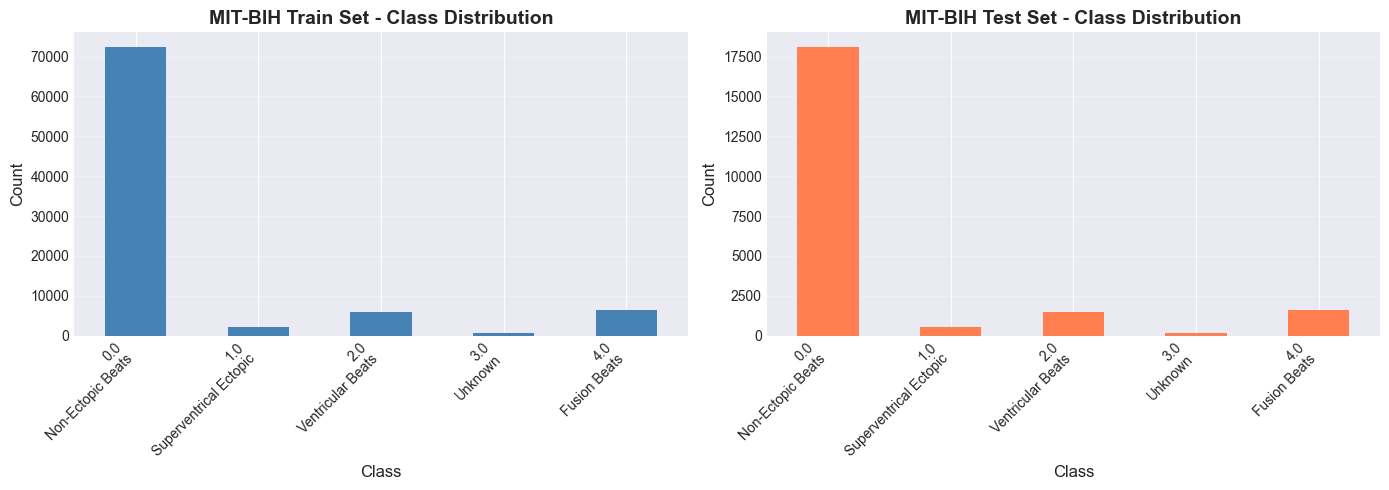

In [5]:
# Class distribution in MIT-BIH datasets
print("=" * 60)
print("MIT-BIH CLASS DISTRIBUTION")
print("=" * 60)

# Train set
train_class_counts = pd.Series(mitbih_train_labels).value_counts().sort_index()
print("\nTrain set class distribution:")
for class_id in sorted(train_class_counts.index):
    count = train_class_counts[class_id]
    percentage = (count / len(mitbih_train_labels)) * 100
    print(f"  Class {class_id} ({CLASS_NAMES[class_id]}): {count:6d} ({percentage:5.2f}%)")

# Test set
test_class_counts = pd.Series(mitbih_test_labels).value_counts().sort_index()
print("\nTest set class distribution:")
for class_id in sorted(test_class_counts.index):
    count = test_class_counts[class_id]
    percentage = (count / len(mitbih_test_labels)) * 100
    print(f"  Class {class_id} ({CLASS_NAMES[class_id]}): {count:6d} ({percentage:5.2f}%)")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set
train_class_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('MIT-BIH Train Set - Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in sorted(train_class_counts.index)], rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Test set
test_class_counts.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('MIT-BIH Test Set - Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in sorted(test_class_counts.index)], rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


**Nhận xét về Class Distribution:**
- **Class imbalance nghiêm trọng**: Class 0 (Non-Ectopic) chiếm ~82.77% - đây là vấn đề lớn cần xử lý khi training
- **Minority classes**: 
  - Class 1 (Superventrical Ectopic): chỉ 2.54% - rất ít
  - Class 3 (Unknown): chỉ 0.73% - cực kỳ ít
- **Consistency**: Train và test có phân phối class gần như giống hệt nhau (~82.76% vs 82.77%) - cho thấy stratified split tốt
- **Recommendation**: Cần áp dụng class weighting, oversampling (SMOTE), hoặc focal loss để xử lý imbalance


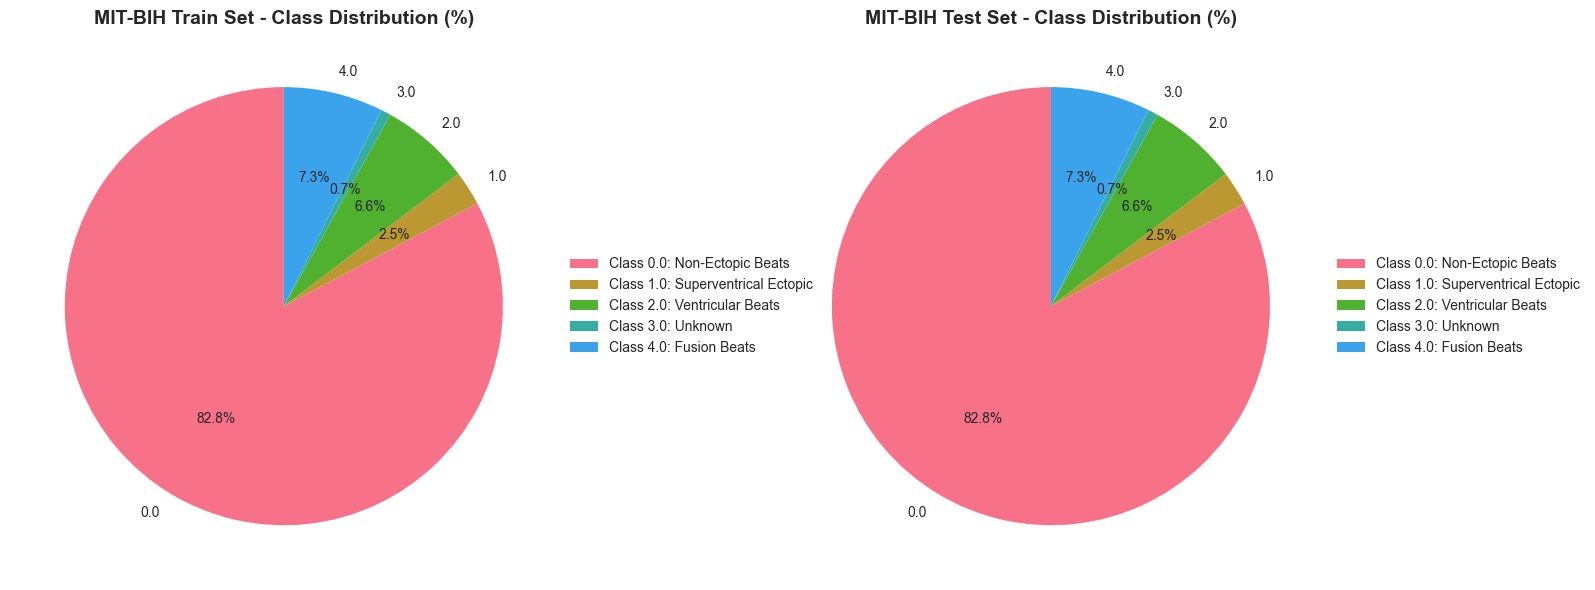

In [6]:
# Pie charts for class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train set pie chart
train_class_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90)
axes[0].set_title('MIT-BIH Train Set - Class Distribution (%)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')
axes[0].legend([f"Class {i}: {CLASS_NAMES[i]}" for i in sorted(train_class_counts.index)], 
               loc='center left', bbox_to_anchor=(1, 0.5))

# Test set pie chart
test_class_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('MIT-BIH Test Set - Class Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].legend([f"Class {i}: {CLASS_NAMES[i]}" for i in sorted(test_class_counts.index)], 
               loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


**Nhận xét về Pie Charts:**
- Pie charts cho thấy rõ ràng sự mất cân bằng nghiêm trọng trong dataset
- Class 0 chiếm phần lớn diện tích (hơn 80%), các class khác chỉ là những lát nhỏ
- Điều này nhấn mạnh tầm quan trọng của việc xử lý class imbalance khi training model
- Có thể cân nhắc undersampling class 0 hoặc oversampling các minority classes


## 4. Signal Visualization


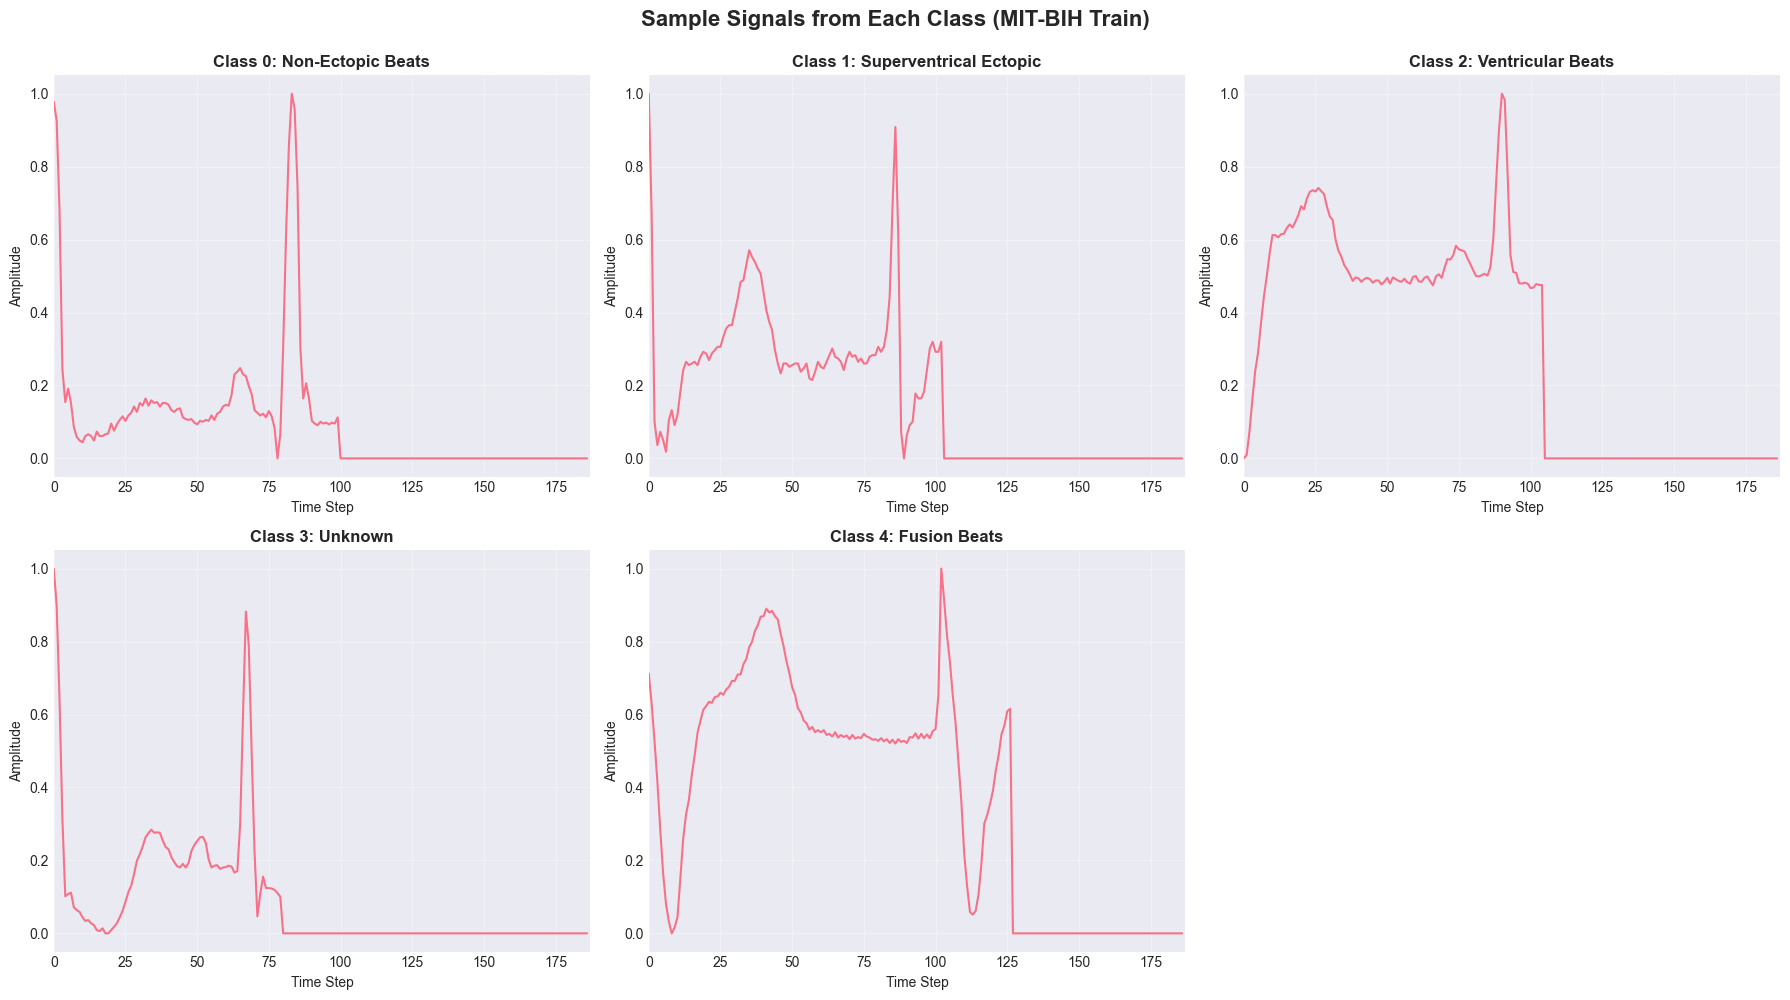

In [7]:
# Visualize sample signals from each class (MIT-BIH Train)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for class_id in range(5):
    # Get first sample of each class
    class_indices = np.where(mitbih_train_labels == class_id)[0]
    if len(class_indices) > 0:
        sample_idx = class_indices[0]
        signal = mitbih_train_signals[sample_idx]
        
        axes[class_id].plot(signal, linewidth=1.5)
        axes[class_id].set_title(f'Class {class_id}: {CLASS_NAMES[class_id]}', fontsize=12, fontweight='bold')
        axes[class_id].set_xlabel('Time Step', fontsize=10)
        axes[class_id].set_ylabel('Amplitude', fontsize=10)
        axes[class_id].grid(True, alpha=0.3)
        axes[class_id].set_xlim(0, len(signal))

# Remove extra subplot
axes[5].axis('off')

plt.suptitle('Sample Signals from Each Class (MIT-BIH Train)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


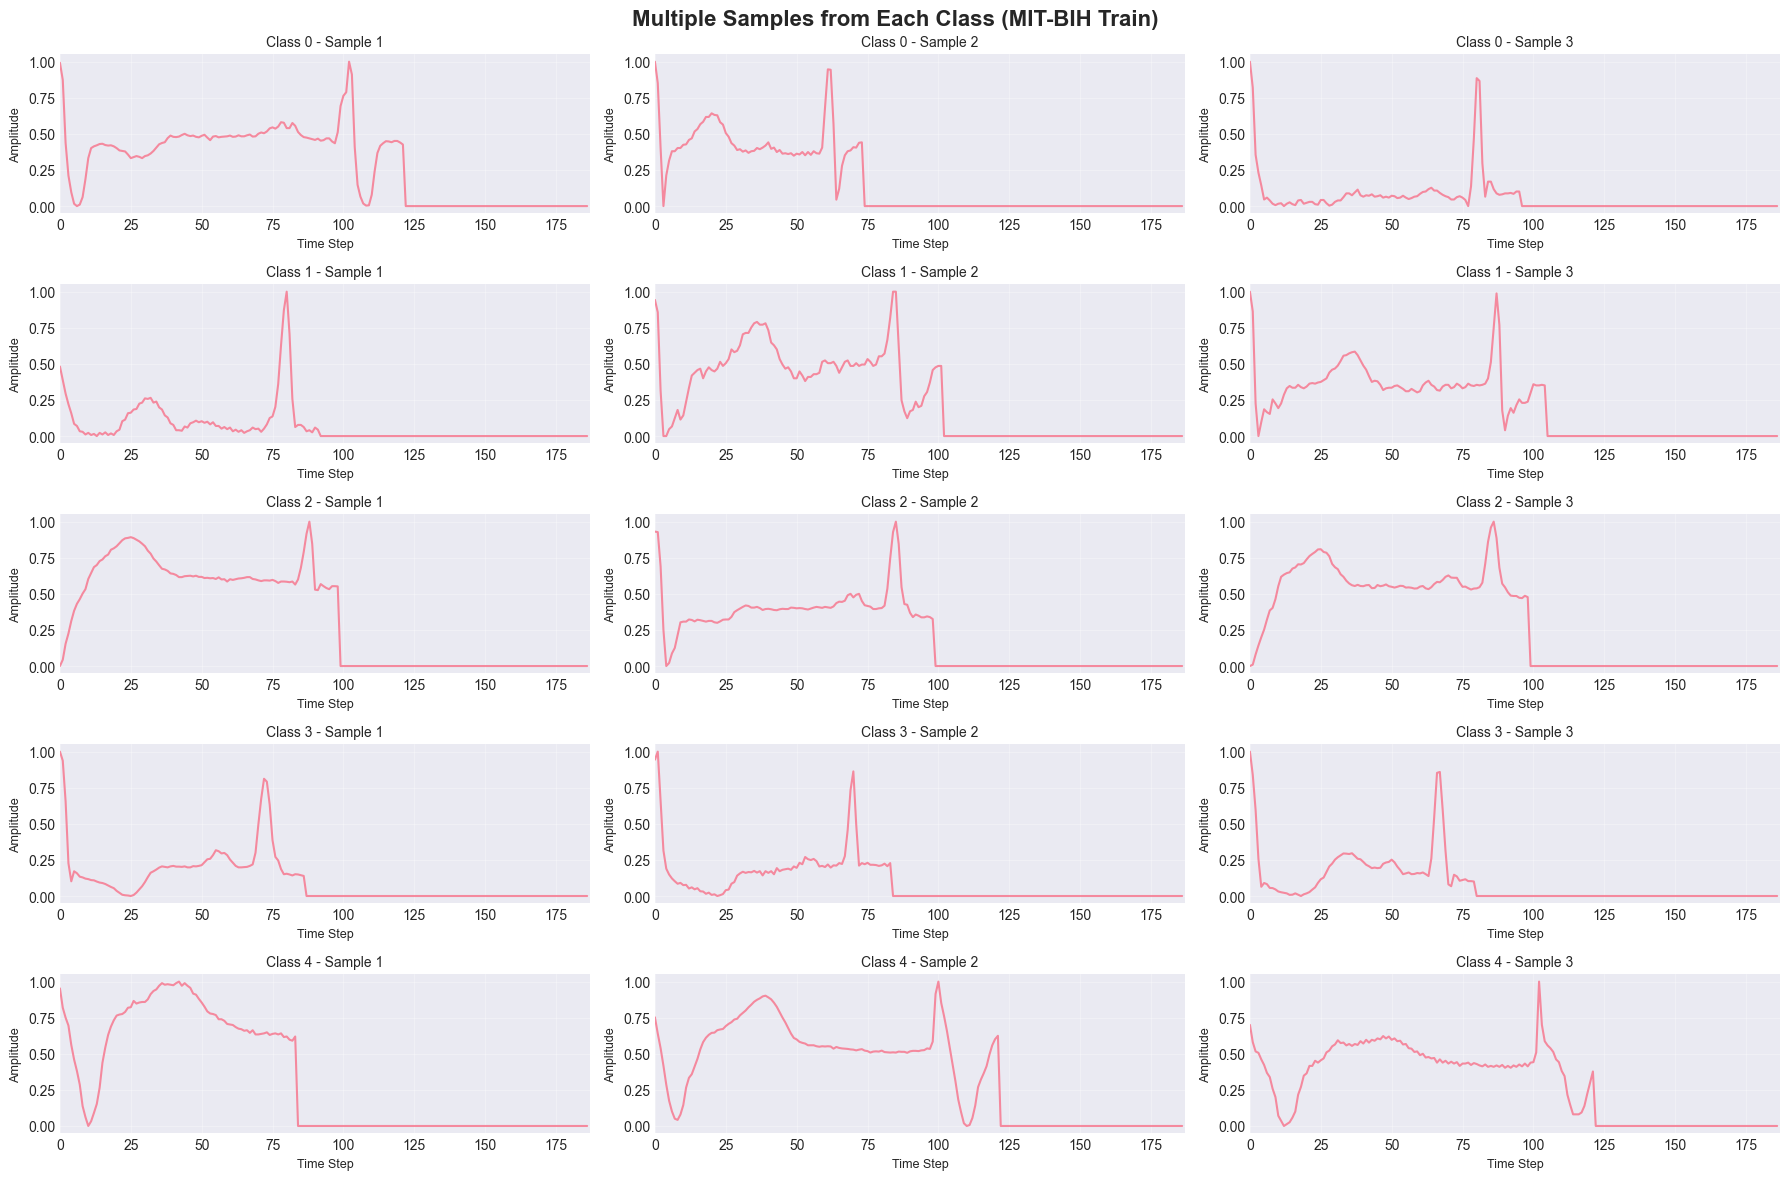

In [8]:
# Visualize multiple samples from each class
fig, axes = plt.subplots(5, 3, figsize=(18, 12))

for class_id in range(5):
    class_indices = np.where(mitbih_train_labels == class_id)[0]
    if len(class_indices) > 0:
        # Plot 3 random samples from each class
        sample_indices = np.random.choice(class_indices, min(3, len(class_indices)), replace=False)
        
        for i, sample_idx in enumerate(sample_indices):
            signal = mitbih_train_signals[sample_idx]
            axes[class_id, i].plot(signal, linewidth=1.5, alpha=0.8)
            axes[class_id, i].set_title(f'Class {class_id} - Sample {i+1}', fontsize=10)
            axes[class_id, i].set_xlabel('Time Step', fontsize=9)
            axes[class_id, i].set_ylabel('Amplitude', fontsize=9)
            axes[class_id, i].grid(True, alpha=0.3)
            axes[class_id, i].set_xlim(0, len(signal))

plt.suptitle('Multiple Samples from Each Class (MIT-BIH Train)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


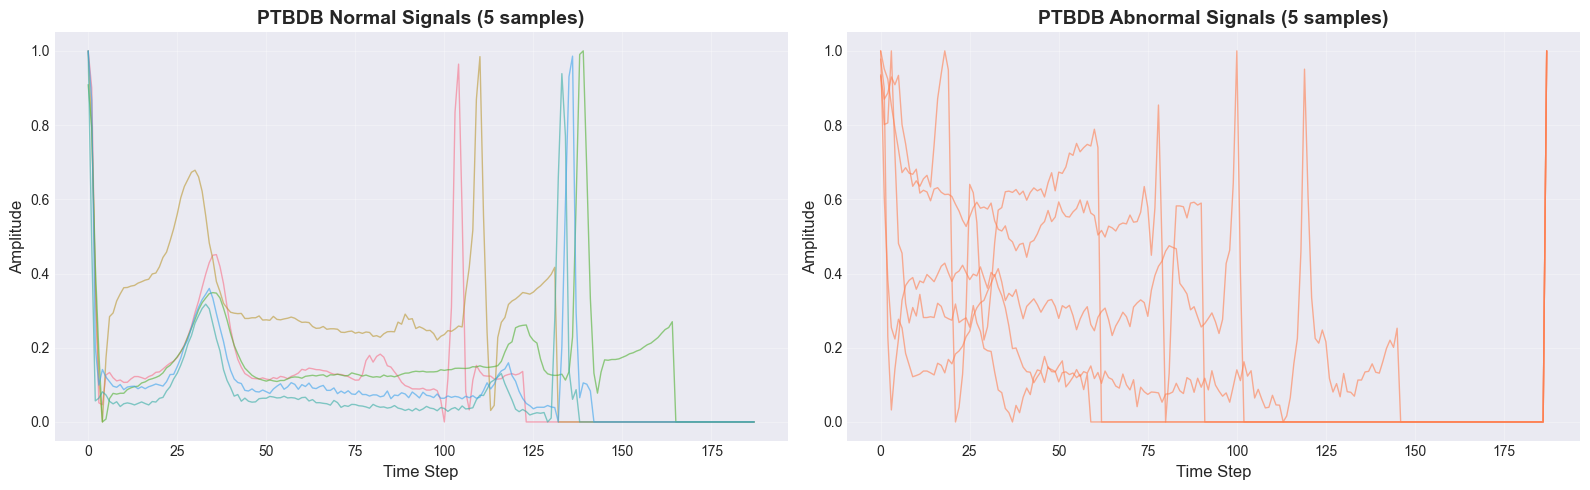

In [9]:
# Visualize PTBDB signals
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Normal signals
for i in range(min(5, len(ptbdb_normal_signals))):
    axes[0].plot(ptbdb_normal_signals[i], alpha=0.6, linewidth=1)
axes[0].set_title('PTBDB Normal Signals (5 samples)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time Step', fontsize=12)
axes[0].set_ylabel('Amplitude', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Abnormal signals
for i in range(min(5, len(ptbdb_abnormal_signals))):
    axes[1].plot(ptbdb_abnormal_signals[i], alpha=0.6, linewidth=1, color='coral')
axes[1].set_title('PTBDB Abnormal Signals (5 samples)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time Step', fontsize=12)
axes[1].set_ylabel('Amplitude', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Nhận xét về PTBDB Normal vs Abnormal:**
- **Distribution overlap**: Có sự overlap đáng kể giữa normal và abnormal trong phân phối signal values
- **Mean difference**: Abnormal có mean cao hơn một chút (0.184 vs 0.158) nhưng không quá lớn
- **Std difference**: Abnormal có std lớn hơn rõ rệt (0.235 vs 0.181) - cho thấy biến động nhiều hơn
- **Class imbalance**: Abnormal nhiều hơn normal gấp 2.6 lần - cần xử lý khi training
- Mặc dù có overlap nhưng vẫn có thể phân biệt được dựa trên các features như std, energy, và pattern recognition


## 5. Statistical Analysis by Class


**Tổng kết các Findings quan trọng:**

1. **Data Quality**: Tất cả datasets đều sạch, không có missing values, đã được normalize về [0,1]

2. **Class Imbalance**: 
   - MIT-BIH: Class 0 chiếm 82.77%, các class khác rất ít (đặc biệt class 3 chỉ 0.73%)
   - PTBDB: Abnormal nhiều hơn Normal 2.6 lần

3. **Signal Characteristics**:
   - MIT-BIH: 187 timesteps, các classes có đặc trưng khác biệt về mean, std, và pattern
   - PTBDB: 188 timesteps, normal ổn định hơn abnormal

4. **Recommendations**:
   - Sử dụng class weights hoặc focal loss để xử lý imbalance
   - Data augmentation để tăng diversity cho minority classes
   - Stratified sampling đã được áp dụng tốt (train/test distribution giống nhau)
   - Có thể sử dụng handcrafted features (mean, std, energy, zero crossings) để hỗ trợ model


In [10]:
# Calculate statistics for each class
print("=" * 60)
print("STATISTICAL ANALYSIS BY CLASS (MIT-BIH Train)")
print("=" * 60)

class_stats = []
for class_id in range(5):
    class_indices = np.where(mitbih_train_labels == class_id)[0]
    if len(class_indices) > 0:
        class_signals = mitbih_train_signals[class_indices]
        
        stats = {
            'Class': class_id,
            'Class Name': CLASS_NAMES[class_id],
            'Count': len(class_indices),
            'Mean': class_signals.mean(),
            'Std': class_signals.std(),
            'Min': class_signals.min(),
            'Max': class_signals.max(),
            'Median': np.median(class_signals),
            'Q25': np.percentile(class_signals, 25),
            'Q75': np.percentile(class_signals, 75)
        }
        class_stats.append(stats)
        
        print(f"\nClass {class_id} ({CLASS_NAMES[class_id]}):")
        print(f"  Count: {stats['Count']}")
        print(f"  Mean: {stats['Mean']:.6f}")
        print(f"  Std: {stats['Std']:.6f}")
        print(f"  Min: {stats['Min']:.6f}")
        print(f"  Max: {stats['Max']:.6f}")
        print(f"  Median: {stats['Median']:.6f}")

# Create DataFrame for easier visualization
stats_df = pd.DataFrame(class_stats)
print("\n" + "=" * 60)
print("Summary Statistics Table:")
print("=" * 60)
print(stats_df[['Class', 'Class Name', 'Count', 'Mean', 'Std', 'Min', 'Max']].to_string(index=False))


STATISTICAL ANALYSIS BY CLASS (MIT-BIH Train)

Class 0 (Non-Ectopic Beats):
  Count: 72471
  Mean: 0.161896
  Std: 0.217563
  Min: 0.000000
  Max: 1.000000
  Median: 0.074303

Class 1 (Superventrical Ectopic):
  Count: 2223
  Mean: 0.194778
  Std: 0.214630
  Min: 0.000000
  Max: 1.000000
  Median: 0.147126

Class 2 (Ventricular Beats):
  Count: 5788
  Mean: 0.243849
  Std: 0.262343
  Min: 0.000000
  Max: 1.000000
  Median: 0.210826

Class 3 (Unknown):
  Count: 641
  Mean: 0.107253
  Std: 0.193049
  Min: 0.000000
  Max: 1.000000
  Median: 0.000000

Class 4 (Fusion Beats):
  Count: 6431
  Mean: 0.250854
  Std: 0.264309
  Min: 0.000000
  Max: 1.000000
  Median: 0.181818

Summary Statistics Table:
 Class             Class Name  Count     Mean      Std  Min  Max
     0      Non-Ectopic Beats  72471 0.161896 0.217563  0.0  1.0
     1 Superventrical Ectopic   2223 0.194778 0.214630  0.0  1.0
     2      Ventricular Beats   5788 0.243849 0.262343  0.0  1.0
     3                Unknown    641 

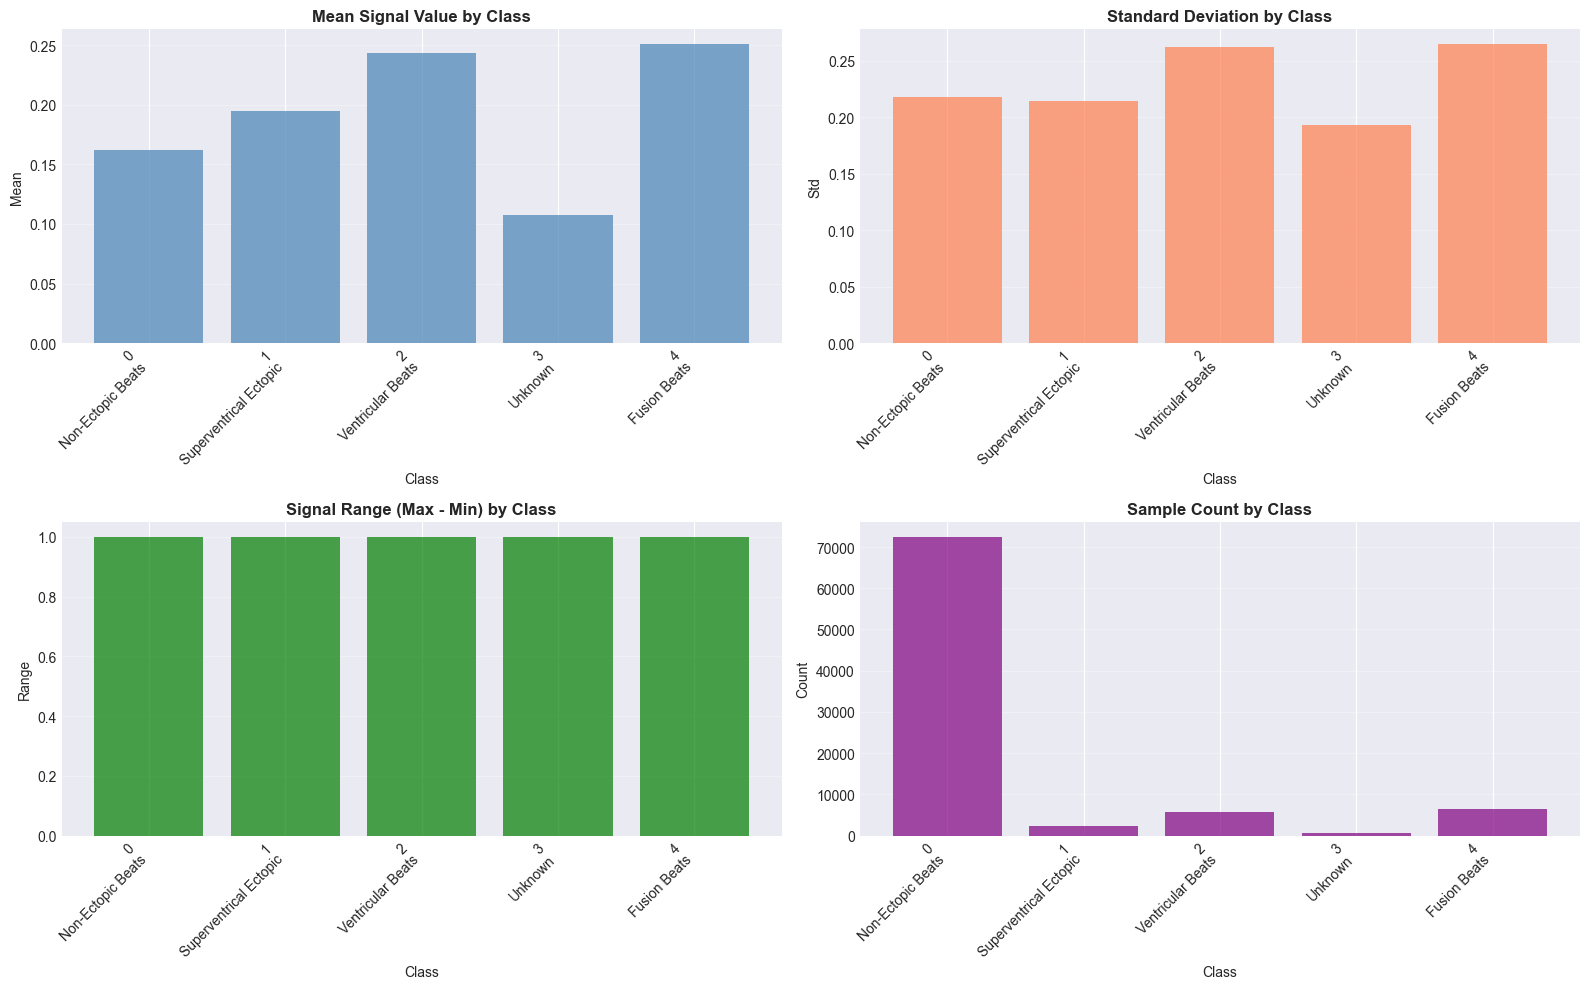

In [11]:
# Visualize statistics by class
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Mean values by class
axes[0, 0].bar(stats_df['Class'], stats_df['Mean'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Mean Signal Value by Class', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Class', fontsize=10)
axes[0, 0].set_ylabel('Mean', fontsize=10)
axes[0, 0].set_xticks(stats_df['Class'])
axes[0, 0].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in stats_df['Class']], rotation=45, ha='right')
axes[0, 0].grid(axis='y', alpha=0.3)

# Std values by class
axes[0, 1].bar(stats_df['Class'], stats_df['Std'], color='coral', alpha=0.7)
axes[0, 1].set_title('Standard Deviation by Class', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Class', fontsize=10)
axes[0, 1].set_ylabel('Std', fontsize=10)
axes[0, 1].set_xticks(stats_df['Class'])
axes[0, 1].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in stats_df['Class']], rotation=45, ha='right')
axes[0, 1].grid(axis='y', alpha=0.3)

# Range (Max - Min) by class
axes[1, 0].bar(stats_df['Class'], stats_df['Max'] - stats_df['Min'], color='green', alpha=0.7)
axes[1, 0].set_title('Signal Range (Max - Min) by Class', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Class', fontsize=10)
axes[1, 0].set_ylabel('Range', fontsize=10)
axes[1, 0].set_xticks(stats_df['Class'])
axes[1, 0].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in stats_df['Class']], rotation=45, ha='right')
axes[1, 0].grid(axis='y', alpha=0.3)

# Count by class
axes[1, 1].bar(stats_df['Class'], stats_df['Count'], color='purple', alpha=0.7)
axes[1, 1].set_title('Sample Count by Class', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Class', fontsize=10)
axes[1, 1].set_ylabel('Count', fontsize=10)
axes[1, 1].set_xticks(stats_df['Class'])
axes[1, 1].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in stats_df['Class']], rotation=45, ha='right')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


**Nhận xét về Statistical Differences giữa các Classes:**
- **Class 0 (Non-Ectopic)**: Mean thấp nhất (0.162), std trung bình (0.218) - signal ổn định nhất
- **Class 2 & 4**: Có mean và std cao nhất (mean ~0.24-0.25, std ~0.26) - signal biến động nhiều nhất
- **Class 3 (Unknown)**: Mean rất thấp (0.107), median = 0 - có thể chứa nhiều giá trị 0 hoặc noise
- **Class 1**: Có đặc điểm trung gian giữa class 0 và các class khác
- Sự khác biệt về statistics cho thấy các classes có thể phân biệt được bằng các features đơn giản


**Nhận xét về Statistics Visualization:**
- Bar charts cho thấy rõ sự khác biệt về mean, std, và range giữa các classes
- Class 2 và 4 có các giá trị statistics cao nhất, phù hợp với việc chúng là các loại beats bất thường
- Class 3 có các giá trị thấp nhất, phù hợp với việc nó có thể chứa nhiều noise
- Sample count chart nhấn mạnh lại vấn đề class imbalance

## 6. Signal Distribution Analysis


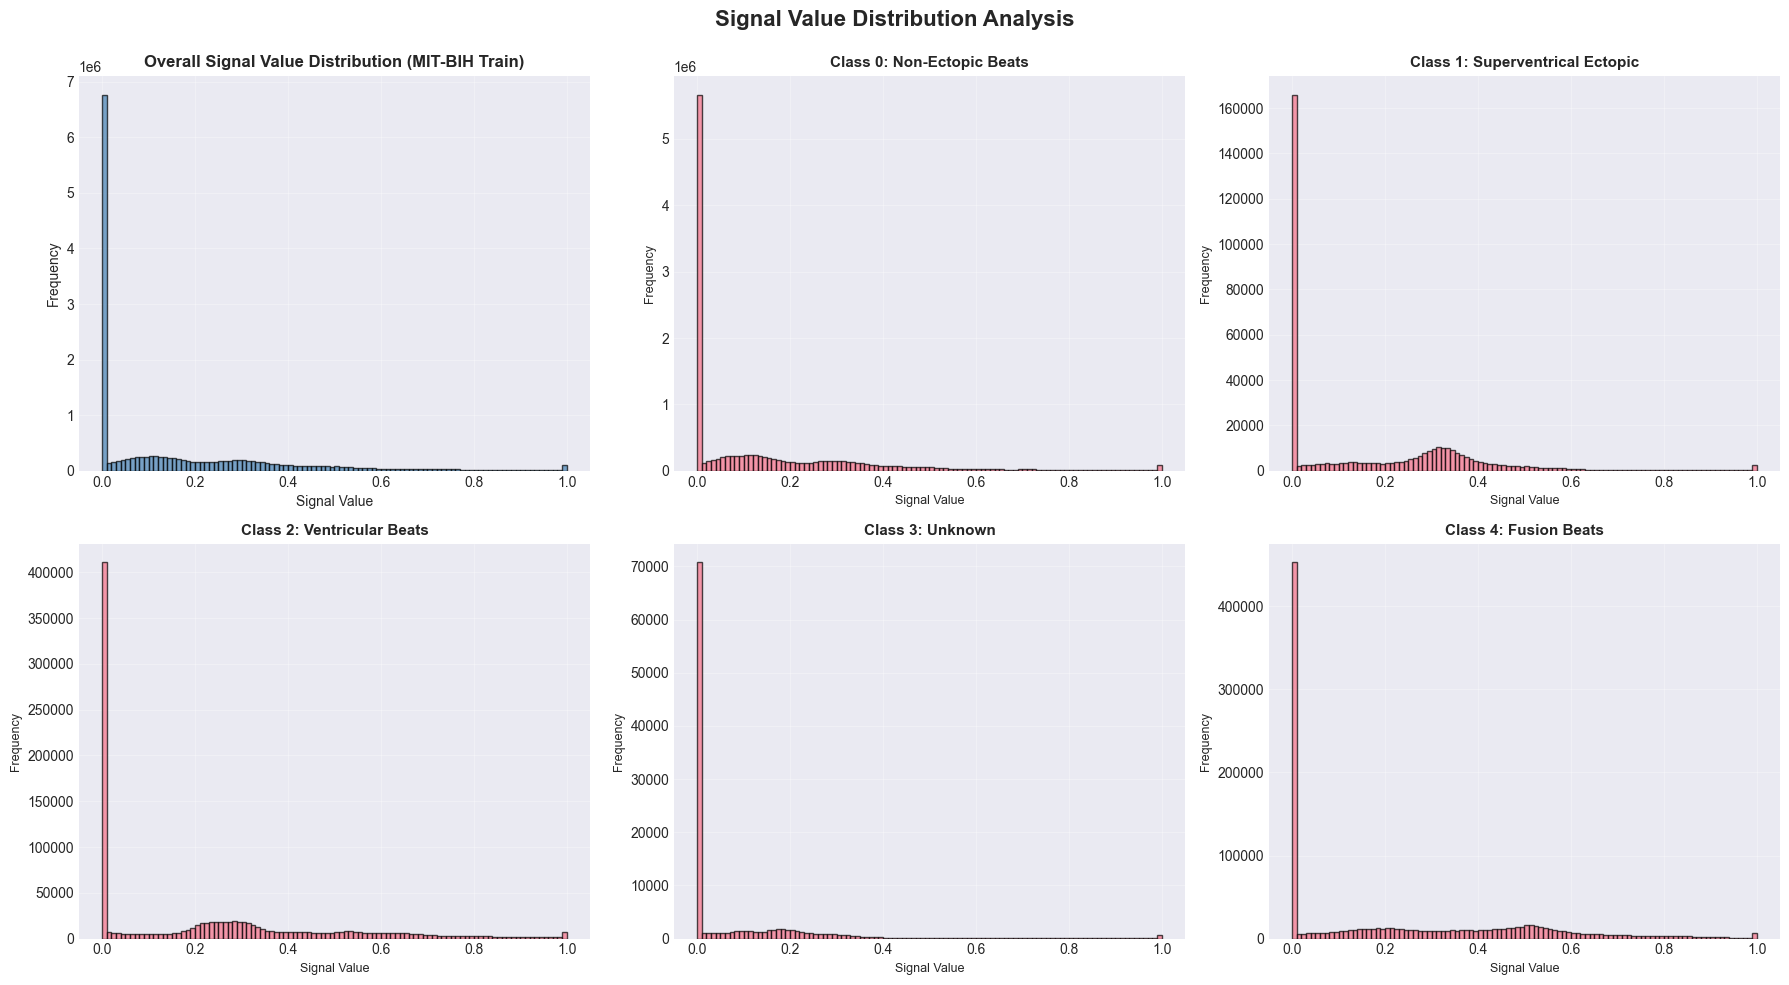

In [12]:
# Distribution of signal values
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Overall distribution
axes[0].hist(mitbih_train_signals.flatten(), bins=100, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_title('Overall Signal Value Distribution (MIT-BIH Train)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Signal Value', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Distribution by class
for class_id in range(5):
    class_indices = np.where(mitbih_train_labels == class_id)[0]
    if len(class_indices) > 0:
        class_signals = mitbih_train_signals[class_indices].flatten()
        axes[class_id + 1].hist(class_signals, bins=100, alpha=0.7, edgecolor='black')
        axes[class_id + 1].set_title(f'Class {class_id}: {CLASS_NAMES[class_id]}', fontsize=11, fontweight='bold')
        axes[class_id + 1].set_xlabel('Signal Value', fontsize=9)
        axes[class_id + 1].set_ylabel('Frequency', fontsize=9)
        axes[class_id + 1].grid(True, alpha=0.3)

plt.suptitle('Signal Value Distribution Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


**Nhận xét về Signal Distribution:**
- **Overall distribution**: Có peak lớn ở giá trị thấp (gần 0), sau đó giảm dần - phân phối lệch phải (right-skewed)
- **Class-specific patterns**: 
  - Class 0: Phân phối tập trung ở giá trị thấp nhất
  - Class 2 & 4: Phân phối rải rác hơn, có nhiều giá trị cao hơn
  - Class 3: Phân phối rất tập trung ở giá trị thấp (nhiều giá trị gần 0)
- Phân phối khác nhau giữa các classes là dấu hiệu tốt cho classification


## 7. Signal Characteristics Analysis


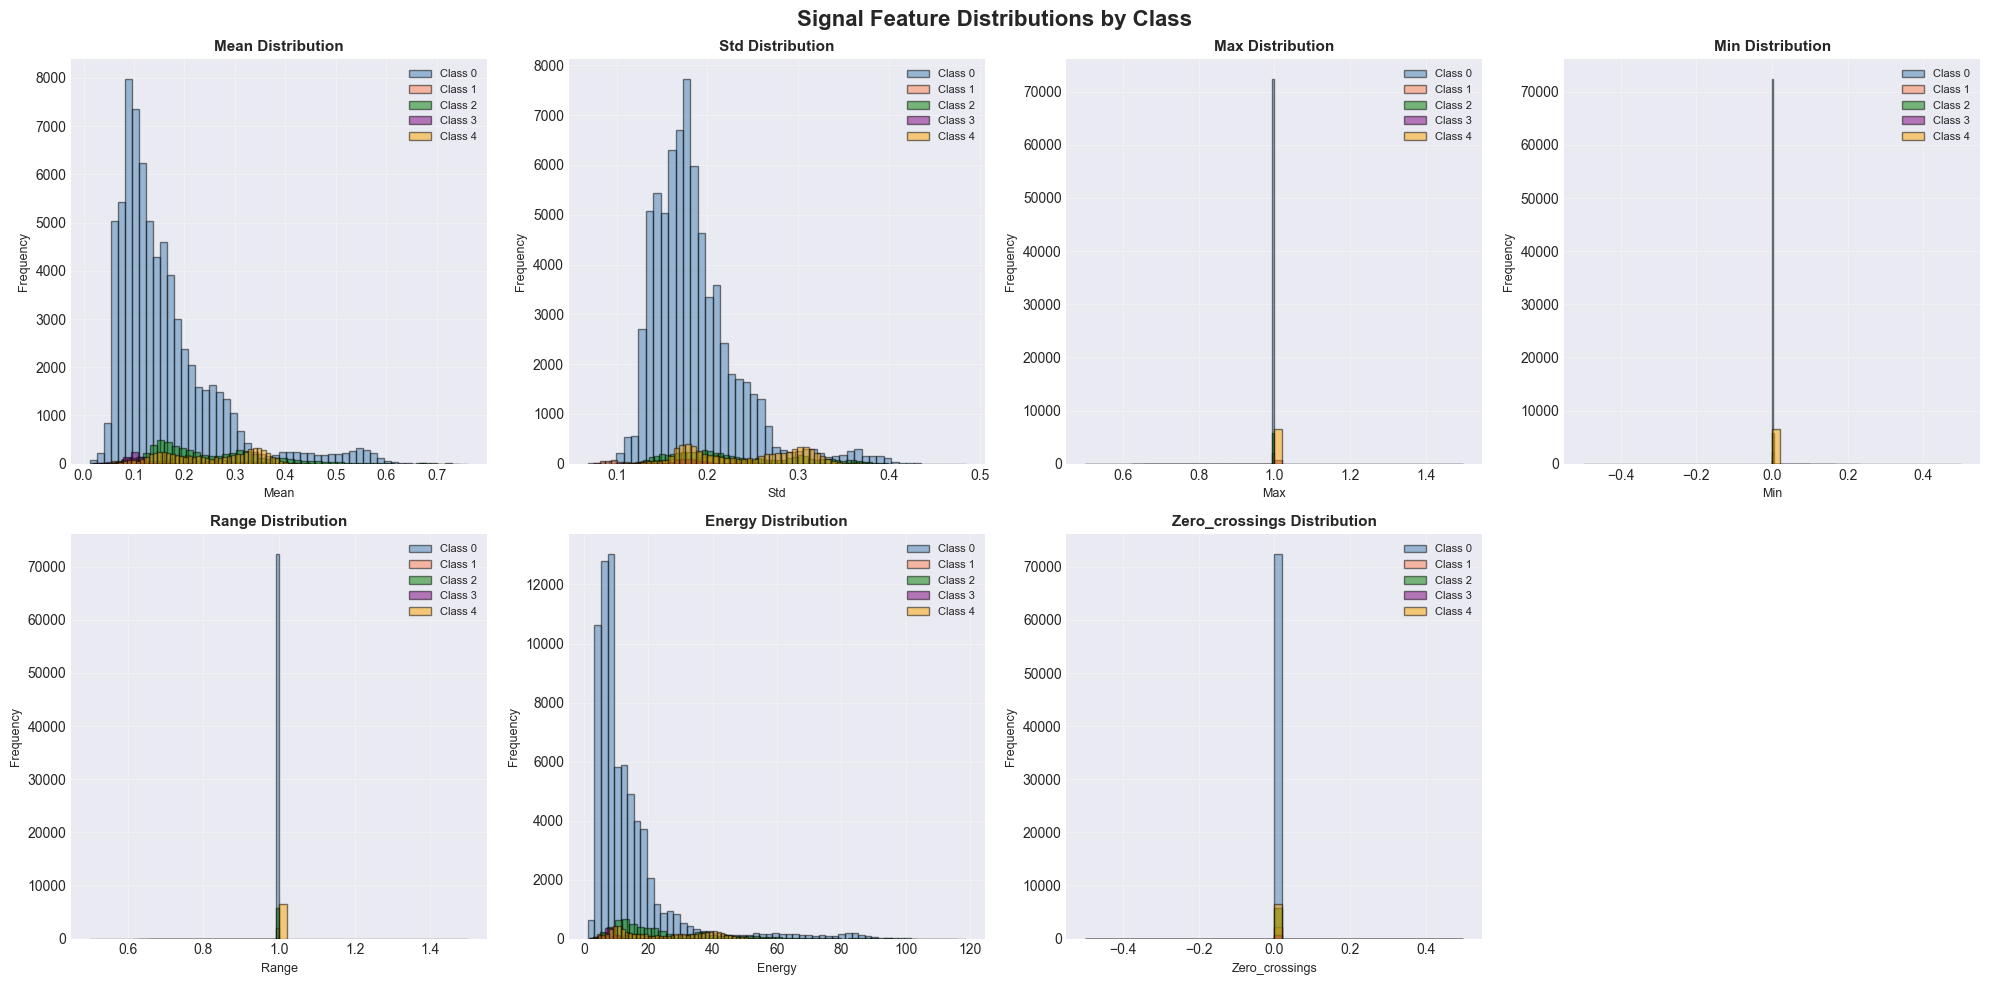

In [13]:
# Calculate signal characteristics for each sample
def calculate_signal_features(signals):
    """Calculate various features for each signal"""
    features = {
        'mean': np.mean(signals, axis=1),
        'std': np.std(signals, axis=1),
        'max': np.max(signals, axis=1),
        'min': np.min(signals, axis=1),
        'range': np.max(signals, axis=1) - np.min(signals, axis=1),
        'energy': np.sum(signals**2, axis=1),
        'zero_crossings': np.array([len(np.where(np.diff(np.signbit(signal)))[0]) for signal in signals])
    }
    return features

# Calculate features for train set
train_features = calculate_signal_features(mitbih_train_signals)

# Visualize feature distributions by class
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

feature_names = ['mean', 'std', 'max', 'min', 'range', 'energy', 'zero_crossings']
colors = ['steelblue', 'coral', 'green', 'purple', 'orange']

for i, feature_name in enumerate(feature_names):
    for class_id in range(5):
        class_indices = np.where(mitbih_train_labels == class_id)[0]
        if len(class_indices) > 0:
            feature_values = train_features[feature_name][class_indices]
            axes[i].hist(feature_values, bins=50, alpha=0.5, label=f'Class {class_id}', 
                        color=colors[class_id], edgecolor='black')
    
    axes[i].set_title(f'{feature_name.capitalize()} Distribution', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feature_name.capitalize(), fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Remove extra subplot
axes[7].axis('off')

plt.suptitle('Signal Feature Distributions by Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


**Nhận xét về Signal Variability:**
- Có sự biến đổi đáng kể trong cùng một class - điều này là bình thường với dữ liệu sinh học
- Class 0 có nhiều biến thể nhất do số lượng mẫu lớn
- Các minority classes (1, 3) có ít biến thể hơn do số lượng mẫu ít
- Sự đa dạng này cho thấy cần dataset augmentation để model học được tính robust


## 8. Comparison: Train vs Test Sets


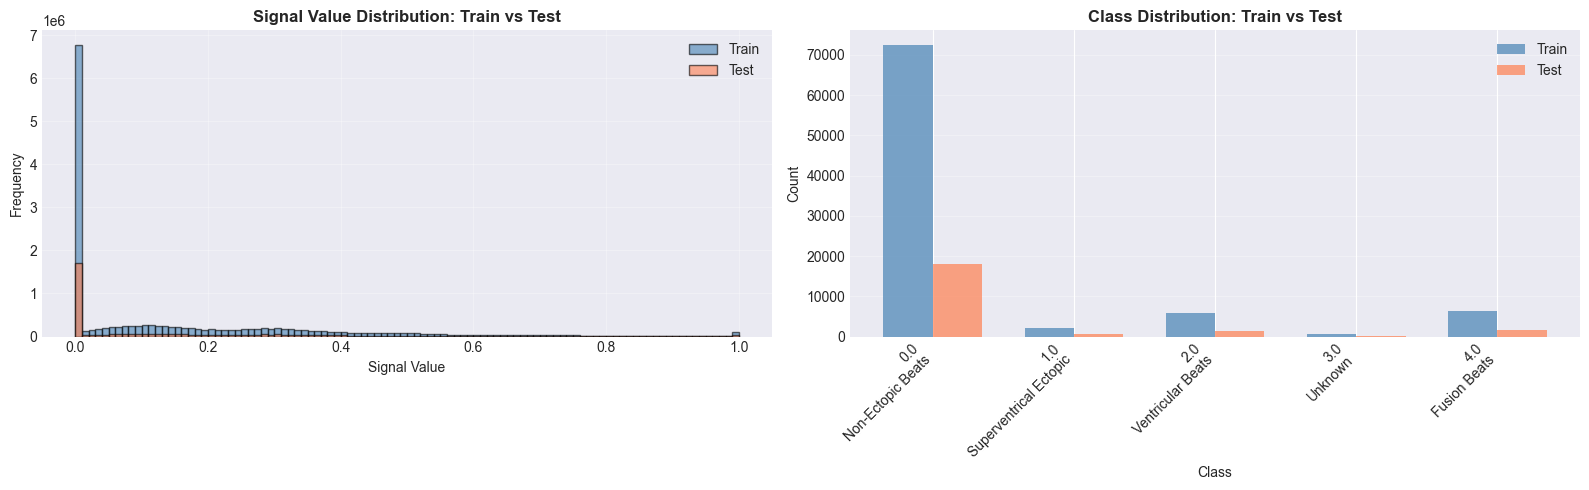

In [14]:
# Compare train and test distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Signal value distribution comparison
axes[0].hist(mitbih_train_signals.flatten(), bins=100, alpha=0.6, label='Train', color='steelblue', edgecolor='black')
axes[0].hist(mitbih_test_signals.flatten(), bins=100, alpha=0.6, label='Test', color='coral', edgecolor='black')
axes[0].set_title('Signal Value Distribution: Train vs Test', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Signal Value', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Class distribution comparison
train_counts = pd.Series(mitbih_train_labels).value_counts().sort_index()
test_counts = pd.Series(mitbih_test_labels).value_counts().sort_index()

x = np.arange(len(train_counts))
width = 0.35
axes[1].bar(x - width/2, train_counts.values, width, label='Train', color='steelblue', alpha=0.7)
axes[1].bar(x + width/2, test_counts.values, width, label='Test', color='coral', alpha=0.7)
axes[1].set_title('Class Distribution: Train vs Test', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=10)
axes[1].set_ylabel('Count', fontsize=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{i}\n{CLASS_NAMES[i]}" for i in train_counts.index], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


**Nhận xét về Train vs Test Comparison:**
- **Distribution consistency**: Phân phối signal values giữa train và test rất giống nhau - cho thấy data split tốt
- **Class distribution**: Tỷ lệ các classes giữa train và test gần như giống hệt nhau (~82.76% vs 82.77% cho class 0)
- Điều này cho thấy dataset được split một cách stratified, đảm bảo tính đại diện của test set
- Model được train trên train set sẽ có performance tương tự trên test set nếu không có overfitting


## 9. PTBDB Dataset Analysis


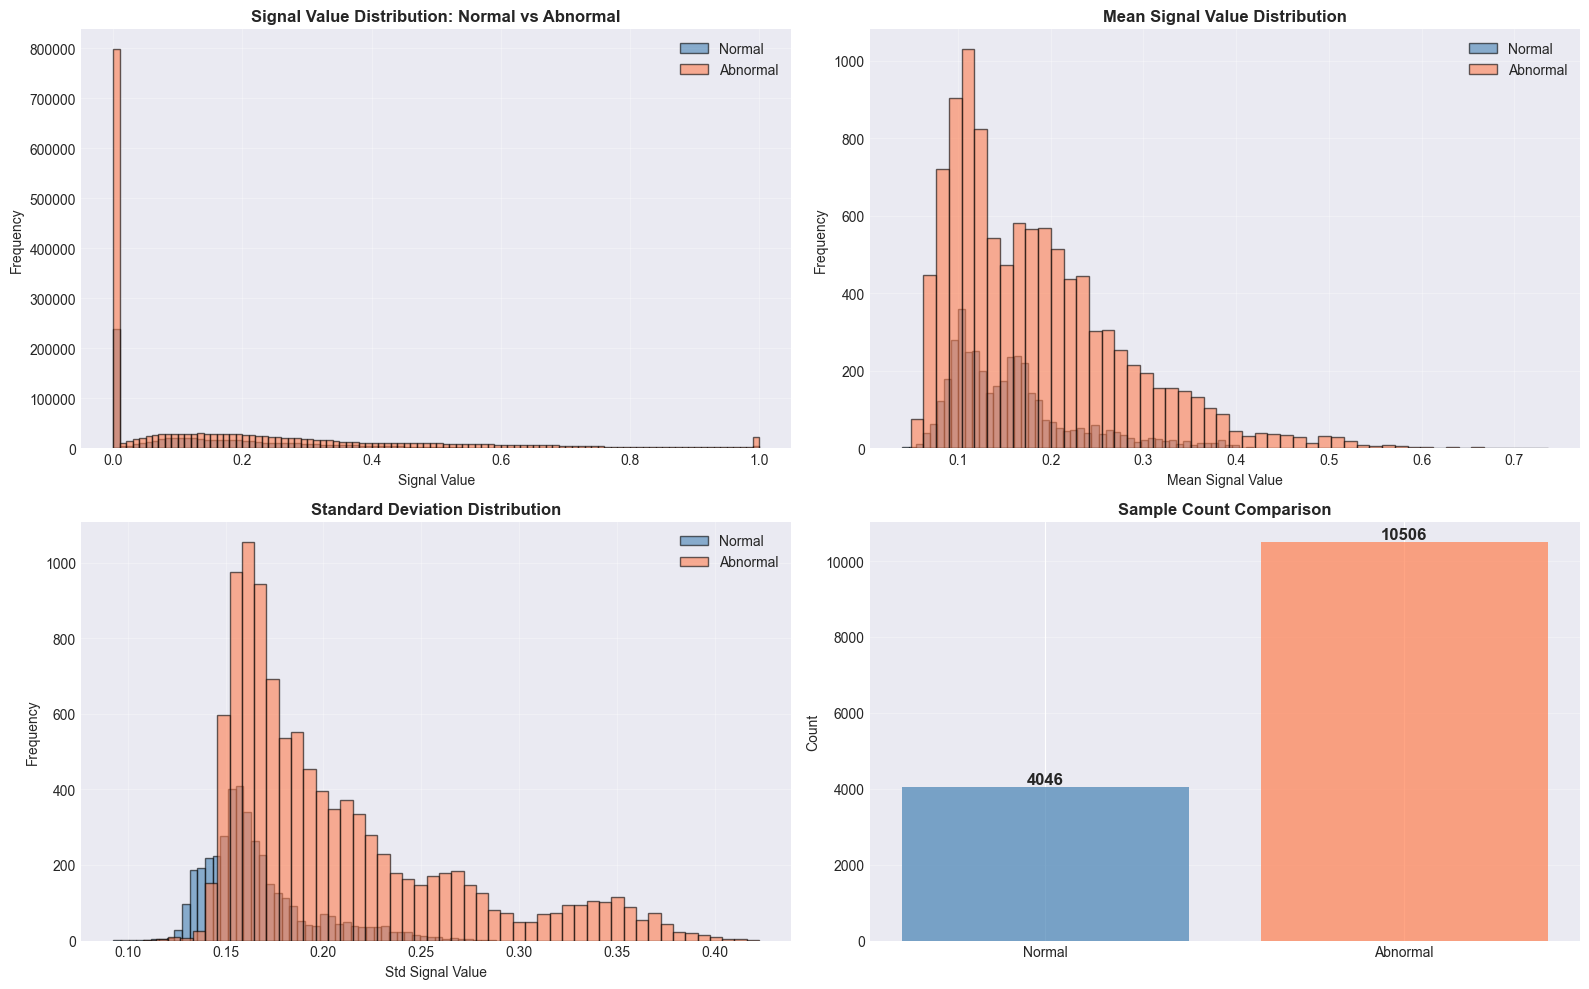

In [15]:
# Compare PTBDB Normal vs Abnormal
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Signal value distribution
axes[0, 0].hist(ptbdb_normal_signals.flatten(), bins=100, alpha=0.6, label='Normal', 
                color='steelblue', edgecolor='black')
axes[0, 0].hist(ptbdb_abnormal_signals.flatten(), bins=100, alpha=0.6, label='Abnormal', 
                color='coral', edgecolor='black')
axes[0, 0].set_title('Signal Value Distribution: Normal vs Abnormal', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Signal Value', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Mean signal values
normal_means = np.mean(ptbdb_normal_signals, axis=1)
abnormal_means = np.mean(ptbdb_abnormal_signals, axis=1)
axes[0, 1].hist(normal_means, bins=50, alpha=0.6, label='Normal', color='steelblue', edgecolor='black')
axes[0, 1].hist(abnormal_means, bins=50, alpha=0.6, label='Abnormal', color='coral', edgecolor='black')
axes[0, 1].set_title('Mean Signal Value Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Mean Signal Value', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Standard deviation
normal_stds = np.std(ptbdb_normal_signals, axis=1)
abnormal_stds = np.std(ptbdb_abnormal_signals, axis=1)
axes[1, 0].hist(normal_stds, bins=50, alpha=0.6, label='Normal', color='steelblue', edgecolor='black')
axes[1, 0].hist(abnormal_stds, bins=50, alpha=0.6, label='Abnormal', color='coral', edgecolor='black')
axes[1, 0].set_title('Standard Deviation Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Std Signal Value', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Sample count comparison
categories = ['Normal', 'Abnormal']
counts = [len(ptbdb_normal_signals), len(ptbdb_abnormal_signals)]
axes[1, 1].bar(categories, counts, color=['steelblue', 'coral'], alpha=0.7)
axes[1, 1].set_title('Sample Count Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Count', fontsize=10)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, count in enumerate(counts):
    axes[1, 1].text(i, count, str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Summary & Key Findings


In [16]:
# Create summary report
print("=" * 60)
print("DATASET EXPLORATION SUMMARY")
print("=" * 60)

print("\n1. MIT-BIH ARRHYTHMIA DATASET:")
print(f"   - Train samples: {len(mitbih_train):,}")
print(f"   - Test samples: {len(mitbih_test):,}")
print(f"   - Signal length: {mitbih_train_signals.shape[1]} timesteps")
print(f"   - Number of classes: 5")
print(f"   - Class imbalance: Yes (Class 0 dominates)")

print("\n2. CLASS DISTRIBUTION (Train):")
for class_id in sorted(train_class_counts.index):
    count = train_class_counts[class_id]
    percentage = (count / len(mitbih_train_labels)) * 100
    print(f"   - Class {class_id} ({CLASS_NAMES[class_id]}): {count:,} ({percentage:.2f}%)")

print("\n3. PTBDB DATASET:")
print(f"   - Normal samples: {len(ptbdb_normal):,}")
print(f"   - Abnormal samples: {len(ptbdb_abnormal):,}")
print(f"   - Signal length: {ptbdb_normal_signals.shape[1]} timesteps")
print(f"   - Binary classification: Normal vs Abnormal")

print("\n4. DATA QUALITY:")
print(f"   - Missing values in MIT-BIH train: {np.isnan(mitbih_train_signals).sum()}")
print(f"   - Missing values in MIT-BIH test: {np.isnan(mitbih_test_signals).sum()}")
print(f"   - Missing values in PTBDB normal: {np.isnan(ptbdb_normal_signals).sum()}")
print(f"   - Missing values in PTBDB abnormal: {np.isnan(ptbdb_abnormal_signals).sum()}")

print("\n5. SIGNAL CHARACTERISTICS:")
print(f"   - MIT-BIH signal range: [{mitbih_train_signals.min():.4f}, {mitbih_train_signals.max():.4f}]")
print(f"   - MIT-BIH mean: {mitbih_train_signals.mean():.4f}, std: {mitbih_train_signals.std():.4f}")
print(f"   - PTBDB normal range: [{ptbdb_normal_signals.min():.4f}, {ptbdb_normal_signals.max():.4f}]")
print(f"   - PTBDB abnormal range: [{ptbdb_abnormal_signals.min():.4f}, {ptbdb_abnormal_signals.max():.4f}]")

print("\n" + "=" * 60)


DATASET EXPLORATION SUMMARY

1. MIT-BIH ARRHYTHMIA DATASET:
   - Train samples: 87,554
   - Test samples: 21,892
   - Signal length: 187 timesteps
   - Number of classes: 5
   - Class imbalance: Yes (Class 0 dominates)

2. CLASS DISTRIBUTION (Train):
   - Class 0.0 (Non-Ectopic Beats): 72,471 (82.77%)
   - Class 1.0 (Superventrical Ectopic): 2,223 (2.54%)
   - Class 2.0 (Ventricular Beats): 5,788 (6.61%)
   - Class 3.0 (Unknown): 641 (0.73%)
   - Class 4.0 (Fusion Beats): 6,431 (7.35%)

3. PTBDB DATASET:
   - Normal samples: 4,046
   - Abnormal samples: 10,506
   - Signal length: 188 timesteps
   - Binary classification: Normal vs Abnormal

4. DATA QUALITY:
   - Missing values in MIT-BIH train: 0
   - Missing values in MIT-BIH test: 0
   - Missing values in PTBDB normal: 0
   - Missing values in PTBDB abnormal: 0

5. SIGNAL CHARACTERISTICS:
   - MIT-BIH signal range: [0.0000, 1.0000]
   - MIT-BIH mean: 0.1743, std: 0.2263
   - PTBDB normal range: [0.0000, 1.0000]
   - PTBDB abnormal ra